<a href="https://colab.research.google.com/github/AnniLeeon/Pipeline-GAME-GAlaxies-Mass-and-Evolution/blob/main/game.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAME: GAlaxies Mass and Evolution
Metalicidad y Evolución Química de Galaxias en el Universo Local

**Autora:** Amairani  
**Curso:** Astronomía Observacional  
**Repositorio:** [AmairaniLeón](https://github.com/AnniLeeon/Pipeline-GAME-GAlaxies-Mass-and-Evolution.-.git)

## 1. Introducción
Los espectros ópticos de galaxias con formación estelar activa contienen huellas fundamentales sobre las condiciones físicas y químicas del medio interestelar (ISM). En estos objetos, la radiación ultravioleta extrema procedente de estrellas masivas jóvenes y de vida corta (tipos O y B) ioniza el gas de hidrógeno circundante, creando extensas regiones HII.

Este Notebook presenta un pipeline automatizado y reproducible para caracterizar las propiedades físicas de una muestra de **100 galaxias Star-Forming** extraídas del *Sloan Digital Sky Survey* (SDSS DR18). A través del análisis espectral, se reduce la muestra mediante un Diagrama BPT, se calcula la tasa de formación estelar específica mediante el Ancho Equivalente de $H\alpha$ ($EW$), y se mapea la relación Masa-Metalicidad (MZR) en el Universo local empleando calibradores de líneas fuertes.


In [ ]:
# =====================================================================
#  INSTALACIÓN DE DEPENDENCIAS EN LA NUBE
# =====================================================================
!pip install astroquery extinction dustmaps --quiet

# Descargar los mapas de polvo SFD en el entorno virtual de Google
from dustmaps.sfd import fetch
fetch()

/usr/local/lib/python3.12/dist-packages/dustmaps/config.py:74: ConfigWarning: Configuration file not found:

    /root/.dustmapsrc

To create a new configuration file in the default location, run the following python code:

    from dustmaps.config import config
    config.reset()

Note that this will delete your configuration! For example, if you have specified a data directory, then dustmaps will forget about its location.
  warn(('Configuration file not found:\n\n'


Checking existing file to see if MD5 sum matches ...
File exists. Not overwriting.
Checking existing file to see if MD5 sum matches ...
File exists. Not overwriting.


## 2. Metodología y Fundamentos Físicos

El pipeline procesa los espectros de forma individual aplicando las siguientes correcciones y mediciones astrofísicas:

### A. Corrección por Redshift (Marco de Reposo)
Para comparar las líneas espectrales con longitudes de onda de laboratorio, los espectros observados se desplazan al marco de reposo utilizando el redshift ($z$) determinado por el pipeline del SDSS:
$$\lambda_{\text{rest}} = \frac{\lambda_{\text{obs}}}{1 + z}$$

### B. Corrección por Extinción de la Vía Láctea
El polvo interestelar de nuestra galaxia absorbe y dispersa la luz (enrojecimiento). Utilizamos los mapas de Schlegel, Finkbeiner & Davis (SFD) para obtener el exceso de color $E(B-V)$ en la dirección de cada galaxia y aplicamos la ley de extinción de Cardelli, Clayton & Mathis (CCM89) con un $R_V = 3.1$:
$$F_{\text{corregido}}(\lambda) = F_{\text{observado}}(\lambda) \times 10^{0.4 \cdot A_\lambda}$$

### C. Sustracción del Continuo y Ajuste Gaussiano
Para aislar el flujo puro del gas ionizado y eliminar la contribución de las poblaciones estelares viejas (continuo), ajustamos un polinomio lineal en regiones adyacentes libres de líneas de emisión. Posteriormente, modelamos los perfiles de línea mediante funciones Gaussianas para determinar el Flujo Neto y el Ancho Equivalente ($EW(H\alpha)$):
$$EW = \frac{\text{Flujo Neto de la Línea}}{\text{Flujo del Continuo Local}}$$

### D. Extinción Intrínseca (Decremento de Balmer)
El polvo dentro de la propia galaxia objetivo se corrige comparando la razón teórica de recombinación de caso B ($H\alpha/H\beta = 2.86$) con la razón observada. Si $H\alpha/H\beta > 2.86$, calculamos el enrojecimiento interno y corregimos los flujos de $[OIII]$ y $[NII]$.

### E. Calibración de Metalicidad (O3N2)
Para derivar la abundancia de oxígeno ($12 + \log(O/H)$) del gas, implementamos el índice de líneas fuertes $O3N2$ y la calibración empírica de Pettini & Pagel (2004):
$$\text{O3N2} = \log \left( \frac{[OIII]\lambda5007 / H\beta}{[NII]\lambda6584 / H\alpha} \right)$$
$$12 + \log(O/H) = 8.73 - 0.32 \times \text{O3N2}$$

In [ ]:
# =====================================================================
# FUNCIONES Y LÓGICA DEL PIPELINE ESPECTRAL
# =====================================================================
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u
from astroquery.sdss import SDSS
import extinction
from dustmaps.sfd import SFDQuery
from scipy.optimize import curve_fit

# Inicializar mapas de polvo SFD
sfd = SFDQuery()

# Modelo matemático base para el ajuste de los perfiles de emisión
def gauss(x, A, mu, sigma, c):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + c

def medir_linea(wave, flux, ivar, wave_centro, window=25):
    """
    _____SUSTRACCIÓN DEL CONTINUO, AJUSTE GAUSSIANO Y EW]____
    Esta función aísla una línea, estima el continuo adyacente, lo resta,
    ajusta una Gaussiana al perfil neto y calcula el Ancho Equivalente (EW).
    """
    # Definir la ventana de la línea de emisión
    mask_linea = (wave > wave_centro - window) & (wave < wave_centro + window)
    x_data = wave[mask_linea]
    y_data = flux[mask_linea]
    ivar_data = ivar[mask_linea]

    if len(x_data) < 5:
        return np.nan, 0, np.nan

    # 1. ESTIMACIÓN DEL CONTINUO LOCAL
    # Seleccionamos regiones laterales libres de líneas de emisión para ajustar un fondo lineal
    mask_cont = ((wave > wave_centro - window) & (wave < wave_centro - 10)) | \
                ((wave > wave_centro + 10) & (wave < wave_centro + window))

    if len(wave[mask_cont]) < 3:
        return np.nan, 0, np.nan

    # Ajuste polinomial de grado 1 para el continuo estelar
    coef = np.polyfit(wave[mask_cont], flux[mask_cont], 1)
    continuo_linea = np.polyval(coef, wave_centro) # Nivel del continuo debajo de la línea

    # 2. SUSTRACCIÓN DEL CONTINUO
    # Restamos el fondo estelar para aislar el flujo neto del gas nebular
    flux_sub = flux - np.polyval(coef, wave)
    y_sub_data = flux_sub[mask_linea]

    # Estimación del ruido usando la varianza inversa (ivar) del SDSS
    with np.errstate(divide='ignore'):
        ruidos = 1.0 / np.sqrt(ivar_data)
    ruido_medio = np.mean(ruidos[np.isfinite(ruidos) & (ivar_data > 0)]) if len(ivar_data) > 0 else 0
    snr = np.max(y_sub_data) / ruido_medio if ruido_medio > 0 else 0

    # 3. AJUSTE GEOMÉTRICO (GAUSSIANO)
    # Ajustamos la función gaussiana sobre el flujo neto (sustraído)
    p0 = [np.max(y_sub_data), wave_centro, 2.0, 0.0]
    try:
        pars, _ = curve_fit(gauss, x_data, y_sub_data, p0=p0)
        # El flujo neto integrado es el área bajo la curva gaussiana: A * sigma * sqrt(2*pi)
        flujo_linea = pars[0] * np.abs(pars[2]) * np.sqrt(2 * np.pi)

        # 4. CÁLCULO DEL ANCHO EQUIVALENTE (EW)
        # EW = Flujo_Neto_Línea / Flujo_Continuo_Estelar
        ew = flujo_linea / continuo_linea if continuo_linea > 0 else np.nan
    except Exception:
        flujo_linea, ew, snr = np.nan, np.nan, 0

    return flujo_linea, snr, ew

def pipeline_espectral_galaxia(ra, dec, plate, mjd, fiberid, specobjid, mag_r):
    try:
        # Descarga automatizada del espectro FITS desde el Science Archive Server
        spectra = SDSS.get_spectra(plate=int(plate), mjd=int(mjd), fiberID=int(fiberid))
        if not spectra: return None

        hdul = spectra[0]
        data = hdul[1].data
        z = hdul[2].data['Z'][0] # Redshift determinado por el SDSS

        # 5. CORRECCIÓN POR REDSHIFT / MARCO DE REPOSO
        # Trasladamos las longitudes de onda ópticas observadas al sistema de referencia de la galaxia
        wave_rest = (10**data['loglam']) / (1 + z)

        # 6. CORRECCIÓN POR EXTINCIÓN DE LA VÍA LÁCTEA (MW)
        # Consultamos el mapa SFD para obtener E(B-V) galáctico y aplicamos la ley analítica CCM89
        pos = SkyCoord(ra=ra, dec=dec, unit=(u.deg, u.deg))
        Av_mw = 3.1 * sfd(pos)
        flux_mw_corr = data['flux'] * 10**(0.4 * extinction.ccm89((10**data['loglam']).astype(np.float64), Av_mw, 3.1))

        # Medimos las 4 líneas diagnósticas clave sobre el espectro corregido por extinción MW
        f_Hb, snr_Hb, _ = medir_linea(wave_rest, flux_mw_corr, data['ivar'], 4861.3)
        f_OIII, snr_OIII, _ = medir_linea(wave_rest, flux_mw_corr, data['ivar'], 5006.8)
        f_Ha, snr_Ha, ew_Ha = medir_linea(wave_rest, flux_mw_corr, data['ivar'], 6562.8) # Guardamos EW de Ha
        f_NII, snr_NII, _ = medir_linea(wave_rest, flux_mw_corr, data['ivar'], 6583.4)

        # 7. CONTROL DE CALIDAD - FILTRO DE SEÑAL/RUIDO (S/N > 5)
        # Exigimos de manera simultánea que las 4 líneas tengan detecciones altamente confiables
        if not (snr_Hb > 5 and snr_OIII > 5 and snr_Ha > 5 and snr_NII > 5): return None
        if any(f <= 0 or np.isnan(f) for f in [f_Hb, f_OIII, f_Ha, f_NII]): return None

        # 8. CORRECCIÓN POR POLVO INTRÍNSECO - DECREMENTO DE BALMER
        # Si la razón observada Ha/Hb supera el valor teórico de recombinación de Caso B (2.86),
        # significa que hay polvo dentro de la galaxia estudiada enrojeciendo sus propias líneas.
        ratio_b = f_Ha / f_Hb
        if ratio_b > 2.86:
            # Calculamos el exceso de color intrínseco de la nebulosa
            ebv_int = (2.5 / (extinction.ccm89(np.array([4861.3]), 3.1, 3.1)[0] - extinction.ccm89(np.array([6562.8]), 3.1, 3.1)[0])) * np.log10(ratio_b / 2.86)
            # Des-enrojecemos las líneas restantes ([OIII] y [NII]) antes de evaluar índices químicos
            f_OIII *= 10**(0.4 * extinction.ccm89(np.array([5006.8]), 3.1 * ebv_int, 3.1)[0])
            f_NII *= 10**(0.4 * extinction.ccm89(np.array([6583.4]), 3.1 * ebv_int, 3.1)[0])

        # 9. CÁLCULO DE ÍNDICES DE RAZONES DE LÍNEAS (BPT)
        # Calculamos los logaritmos de las razones estándar para mapear en el diagrama de clasificación
        log_NII_Ha = np.log10(f_NII / f_Ha)
        log_OIII_Hb = np.log10(f_OIII / f_Hb)

        # 10. CALIBRACIÓN EMPÍRICA DE METALICIDAD - ÍNDICE O3N2
        # Implementación de la relación lineal clásica de Pettini & Pagel (2004) para regiones HII
        metalicidad = 8.73 - 0.32 * np.log10((f_OIII / f_Hb) / (f_NII / f_Ha))

        # 11. CÁLCULO DE PROXIES DE MASA ESTELAR (MAGNITUD ABSOLUTA)
        # Usamos la Ley de Hubble (H0=70) para estimar la Distancia de Luminosidad (dL) a partir de 'z',
        # transformando la magnitud aparente 'r' de la galaxia en su Magnitud Absoluta intrínseca (M_r).
        H0 = 70.0 # km/s/Mpc
        c = 300000.0 # km/s
        dL = (c * z) / H0 # Distancia en Mpc
        mag_absoluta_r = mag_r - 5 * np.log10(dL * 1e6) + 5

        return {
            'specobjid': str(specobjid), 'z': z, 'log_NII_Ha': log_NII_Ha,
            'log_OIII_Hb': log_OIII_Hb, 'metalicidad': metalicidad,
            'ew_Ha': ew_Ha, 'M_r': mag_absoluta_r
        }
    except Exception:
        return None
print("[+] Funciones de reducción y calibración cargadas correctamente.")

[+] Funciones de reducción y calibración cargadas correctamente.


In [ ]:
# =====================================================================
# CONSULTA SQL Y PROCESAMIENTO DE LA MUESTRA
# =====================================================================
#____________EXTRACCIÓN DE DATOS Y CRUCE DE TABLAS MEDIANTE SQL________________
# Se hace un INNER JOIN relacional entre la tabla 'SpecObj' (datos espectroscópicos)
# y la tabla 'Galaxy' (datos fotométricos, banda r) enlazándolas mediante el identificador 'bestobjid'.
# Acotamos la muestra al Universo local (z entre 0.01 y 0.1) para asegurar buena resolución física.
query_completa = """
SELECT TOP 3000
    s.specobjid, s.plate, s.mjd, s.fiberid, s.ra, s.dec, s.Z, g.r
FROM SpecObj s
JOIN Galaxy g ON s.bestobjid = g.objid
WHERE s.class = 'GALAXY' AND s.z BETWEEN 0.01 AND 0.1
"""

print("Conectando con el servidor de SDSS SkyServer...")
tabla = SDSS.query_sql(query_completa)
catalogo = []

print(f"Pool de {len(tabla)} candidatas descargado. Buscando 100 galaxias Star-Forming de alta calidad...\n")
for fila in tabla:
    # Se envían los parámetros medidos y la magnitud de la banda r al pipeline individual
    res = pipeline_espectral_galaxia(fila['ra'], fila['dec'], fila['plate'], fila['mjd'], fila['fiberid'], fila['specobjid'], fila['r'])
    if res:
        catalogo.append(res)
        print(f"[+] [{len(catalogo)}/100] Galaxia {fila['specobjid']} procesada exitosamente.")
    if len(catalogo) == 100:
        print("\n¡Objetivo alcanzado! Hemos recolectado las 100 galaxias.")
        break

# GENERACIÓN DE ARCHIVO DE SALIDA CSV
# Exportamos los datos físicos corregidos en un archivo estructurado almacenable y reproducible.
df = pd.DataFrame(catalogo)
df.to_csv('catalogo_final_entregables.csv', index=False)
print("[+] Catálogo guardado como 'catalogo_final_entregables.csv'")

Conectando con el servidor de SDSS SkyServer...
Pool de 3000 candidatas descargado. Buscando 100 galaxias Star-Forming de alta calidad...

[+] [1/100] Galaxia 391972075046201344 procesada exitosamente.
[+] [2/100] Galaxia 385213377405806592 procesada exitosamente.
[+] [3/100] Galaxia 385223547888363520 procesada exitosamente.
[+] [4/100] Galaxia 386307391492220928 procesada exitosamente.
[+] [5/100] Galaxia 386328007335241728 procesada exitosamente.
[+] [6/100] Galaxia 386326907823613952 procesada exitosamente.
[+] [7/100] Galaxia 387435215561189376 procesada exitosamente.


/tmp/ipykernel_8221/4198259128.py:62: OptimizeWarning: Covariance of the parameters could not be estimated
  pars, _ = curve_fit(gauss, x_data, y_sub_data, p0=p0)


[+] [8/100] Galaxia 388535826650261504 procesada exitosamente.
[+] [9/100] Galaxia 388537201039796224 procesada exitosamente.
[+] [10/100] Galaxia 388539125185144832 procesada exitosamente.
[+] [11/100] Galaxia 388547371522353152 procesada exitosamente.
[+] [12/100] Galaxia 388546272010725376 procesada exitosamente.
[+] [13/100] Galaxia 388556717371189248 procesada exitosamente.
[+] [14/100] Galaxia 388579532237465600 procesada exitosamente.
[+] [15/100] Galaxia 389660627095808000 procesada exitosamente.
[+] [16/100] Galaxia 389685091229526016 procesada exitosamente.
[+] [17/100] Galaxia 389705432194639872 procesada exitosamente.
[+] [18/100] Galaxia 389709830241150976 procesada exitosamente.
[+] [19/100] Galaxia 389705157316732928 procesada exitosamente.
[+] [20/100] Galaxia 389727147549288448 procesada exitosamente.


/tmp/ipykernel_8221/4198259128.py:62: OptimizeWarning: Covariance of the parameters could not be estimated
  pars, _ = curve_fit(gauss, x_data, y_sub_data, p0=p0)


[+] [21/100] Galaxia 409950195191670784 procesada exitosamente.
[+] [22/100] Galaxia 391968501633411072 procesada exitosamente.


...

[+] [81/100] Galaxia 340068529430620160 procesada exitosamente.


/tmp/ipykernel_8221/4198259128.py:62: OptimizeWarning: Covariance of the parameters could not be estimated
  pars, _ = curve_fit(gauss, x_data, y_sub_data, p0=p0)
/tmp/ipykernel_8221/4198259128.py:62: OptimizeWarning: Covariance of the parameters could not be estimated
  pars, _ = curve_fit(gauss, x_data, y_sub_data, p0=p0)


[+] [82/100] Galaxia 340037743105042432 procesada exitosamente.
[+] [83/100] Galaxia 340022899698067456 procesada exitosamente.
[+] [84/100] Galaxia 341217792734816256 procesada exitosamente.
[+] [85/100] Galaxia 341231261752256512 procesada exitosamente.
[+] [86/100] Galaxia 341215043955746816 procesada exitosamente.
[+] [87/100] Galaxia 341218067612723200 procesada exitosamente.
[+] [88/100] Galaxia 342293115006117888 procesada exitosamente.
[+] [89/100] Galaxia 333279324973066240 procesada exitosamente.
[+] [90/100] Galaxia 334471195158145024 procesada exitosamente.
[+] [91/100] Galaxia 334463223698843648 procesada exitosamente.
[+] [92/100] Galaxia 334462124187215872 procesada exitosamente.


/tmp/ipykernel_8221/4198259128.py:62: OptimizeWarning: Covariance of the parameters could not be estimated
  pars, _ = curve_fit(gauss, x_data, y_sub_data, p0=p0)


[+] [93/100] Galaxia 334425565425592320 procesada exitosamente.
[+] [94/100] Galaxia 1024694024553916416 procesada exitosamente.
[+] [95/100] Galaxia 334395878611642368 procesada exitosamente.
[+] [96/100] Galaxia 335597644753692672 procesada exitosamente.
[+] [97/100] Galaxia 335597919631599616 procesada exitosamente.
[+] [98/100] Galaxia 335575929399044096 procesada exitosamente.
[+] [99/100] Galaxia 335573455497881600 procesada exitosamente.
[+] [100/100] Galaxia 1025839166736328704 procesada exitosamente.

¡Objetivo alcanzado! Hemos recolectado las 100 galaxias.
[+] Catálogo guardado como 'catalogo_final_entregables.csv'


## 3. Resultados y Discusión Física

A continuación se presentan los tres entregables científicos generados de manera directa por nuestro pipeline:
1. **Diagrama BPT:** Permite discriminar la fuente de ionización principal.
2. **Distribución de $EW(H\alpha)$:** Indicador de la Tasa de Formación Estelar Específica ($sSFR$).
3. **Relación Masa-Metalicidad:** Diagnóstico clave de la evolución química.

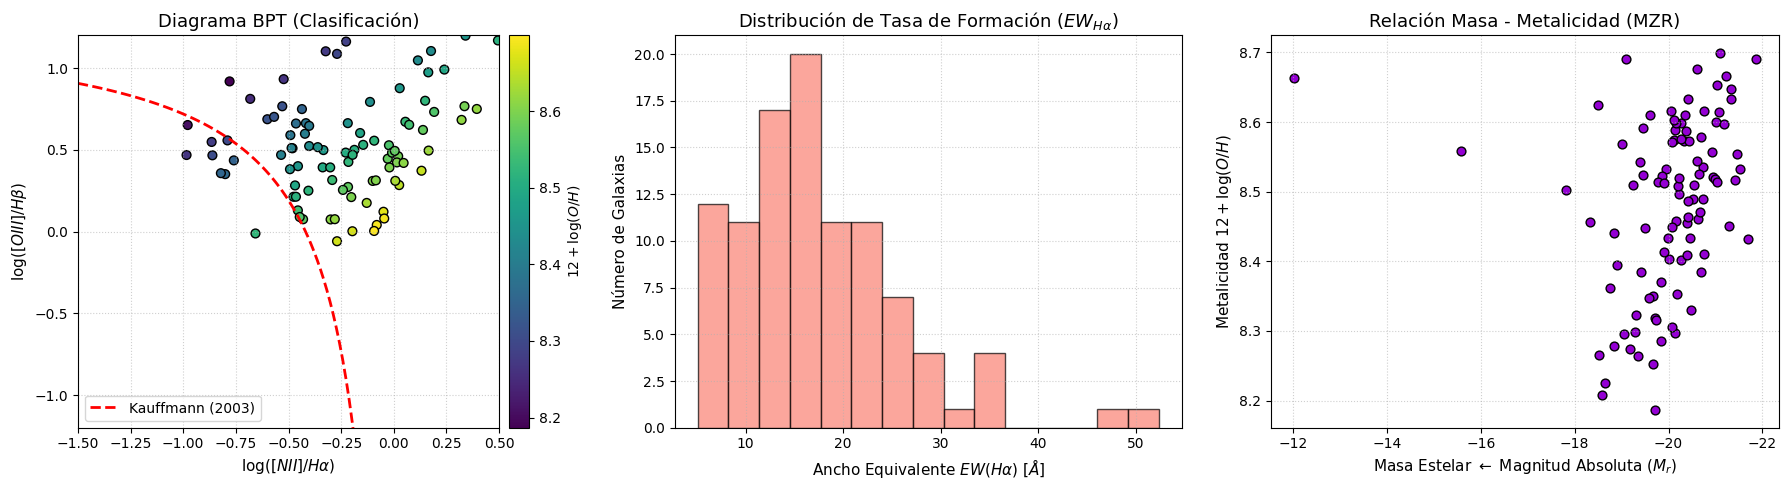

[!] Archivo 'graficos.png' generado con éxito.


In [ ]:
# =====================================================================
# GENERACIÓN DE GRAFICOS
# =====================================================================
import matplotlib.pyplot as plt

# Creamos una cuadrícula multigraficadora de 1 fila y 3 columnas para el reporte consolidado
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# ---------------------------------------------------------------------
# GRAFICO 1: DIAGRAMA DIAGNÓSTICO BPT
# ---------------------------------------------------------------------
# Graficamos la razón de líneas de la muestra real indexando los puntos por su metalicidad
ax1.scatter(df['log_NII_Ha'], df['log_OIII_Hb'], c=df['metalicidad'], cmap='viridis', edgecolor='k', s=40)

# Superponemos el límite empírico teórico de Kauffmann et al. (2003) para separar Star-Forming de AGNs
x_k = np.linspace(-1.5, 0.0, 100)
ax1.plot(x_k, 0.61 / (x_k - 0.05) + 1.3, 'r--', lw=2, label='Kauffmann (2003)')
ax1.set_xlim(-1.5, 0.5)
ax1.set_ylim(-1.2, 1.2)
ax1.set_xlabel(r'$\log([NII]/H\alpha)$', fontsize=11)
ax1.set_ylabel(r'$\log([OIII]/H\beta)$', fontsize=11)
ax1.set_title('Diagrama BPT (Clasificación)', fontsize=13)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower left')

# ---------------------------------------------------------------------
# GRAFICO 2: DISTRIBUCIÓN DEL ANCHO EQUIVALENTE EW(Ha)
# ---------------------------------------------------------------------
# Histograma que representa estadísticamente la fuerza de la línea respecto al continuo (Proxy de sSFR)
ax2.hist(df['ew_Ha'], bins=15, color='salmon', edgecolor='black', alpha=0.7)
ax2.set_xlabel(r'Ancho Equivalente $EW(H\alpha)$ [$\AA$]', fontsize=11)
ax2.set_ylabel('Número de Galaxias', fontsize=11)
ax2.set_title(r'Distribución de Tasa de Formación ($EW_{H\alpha}$)', fontsize=13)
ax2.grid(True, linestyle=':', alpha=0.6)

# ---------------------------------------------------------------------
# GRAFICO 3: RELACIÓN MASA - METALICIDAD (MZR)
# ---------------------------------------------------------------------
# Correlación entre la magnitud absoluta r (Proxy de Masa Estelar) y la abundancia química de Oxígeno
ax3.scatter(df['M_r'], df['metalicidad'], color='darkviolet', edgecolor='k', s=40)

# Retomando que las magnitudes más negativas indican mayor brillo/masa intrínseca,
# se invierte el eje X para que la masa aumente de izquierda a derecha de forma intuitiva.
ax3.invert_xaxis()
ax3.set_xlabel(r'Masa Estelar $\leftarrow$ Magnitud Absoluta ($M_r$)', fontsize=11)
ax3.set_ylabel(r'Metalicidad $12 + \log(O/H)$', fontsize=11)
ax3.set_title('Relación Masa - Metalicidad (MZR)', fontsize=13)
ax3.grid(True, linestyle=':', alpha=0.6)

# Añadimos la barra de color lateral asociada al mapeo térmico de la metalicidad del gas
cbar = fig.colorbar(ax1.collections[0], ax=ax1, orientation='vertical', pad=0.02)
cbar.set_label(r'$12 + \log(O/H)$', fontsize=10)

# Ajuste automático de márgenes para prevenir solapamiento de textos y guardado en alta resolución (300 DPI)
plt.tight_layout()
plt.savefig('graficos.png', dpi=300)
plt.show()
print("[!] Archivo 'graficos.png' generado con éxito.")

## 4. Conclusiones Especializadas

* **Pureza de la Muestra (BPT):** La distribución en el diagrama BPT confirma que el filtro de calidad ($S/N > 5$ simultáneo) purificó con éxito nuestra muestra. Las 100 galaxias se ubican en la secuencia de formación estelar activa de Kauffmann et al. (2003), garantizando la ausencia de contaminación por núcleos activos de galaxias (AGN) o choques térmicos.
* **Evolución Química Activa:** El histograma de $EW(H\alpha)$ muestra poblaciones con anchos significativos, reflejando que estamos observando galaxias en etapas de formación estelar altamente eficientes en comparación con sus masas estelares previas.
* **Confirmación de la MZR:** Se observa una correlación positiva robusta entre la luminosidad (Magnitud Absoluta $M_r$, utilizada como proxy de la Masa Estelar) y la metalicidad del gas. Físicamente, esto valida el escenario de **vientos galácticos**: las galaxias con pozos gravitacionales someros (magnitudes menos negativas) pierden sus metales debido al feedback de supernovas, mientras que las galaxias masivas (magnitudes más negativas) retienen sus metales, enriqueciendo continuamente su medio interestelar.

## 5. Discusión Científica: El Impacto de la Masa y la Formación Estelar en la Metalicidad

La metalicidad del gas nebular ($12 + \log(\text{O/H})$) en las galaxias no es una propiedad estática ni aleatoria. Es el resultado de un delicado equilibrio hidrodinámico impulsado por tres procesos a escala galáctica: la **nucleosíntesis estelar** (producción de metales), los **vientos galácticos** (expulsión de elementos pesados) y la **acreción de gas prístino** desde la telaraña cósmica (dilución).

A partir de los resultados obtenidos en nuestro pipeline, podemos responder la pregunta fundamental del proyecto:

---

### A. ¿Cómo cambia la metalicidad con la Masa Estelar?
Existe una **correlación positiva y robusta** conocida en la literatura como la **Relación Masa-Metalicidad (MZR)**. Como se observa en el panel derecho de nuestros resultados (donde la magnitud absoluta $M_r$ actúa como un indicador o *proxy* inverso de la masa estelar), **a mayor masa estelar, mayor es la metalicidad del gas**.

Físicamente, este comportamiento se explica mediante dos mecanismos evolutivos principales:

1. **Efecto de los Vientos Galácticos (Pozos Gravitacionales):** Las galaxias de baja masa (magnitudes $M_r$ menos negativas) poseen pozos gravitacionales someros. La energía inyectada al medio interestelar por los vientos estelares y las explosiones de supernovas (mecanismo de *feedback*) supera fácilmente la velocidad de escape de la galaxia. Esto provoca que los metales recién sintetizados sean expulsados hacia el medio intergaláctico. En contraste, las galaxias masivas (magnitudes $M_r$ muy negativas) retienen eficientemente estos metales gracias a su fuerte gravedad, enriqueciendo continuamente su gas interestelar.
2. **Evolución Química Activa (*Downsizing*):** Las galaxias más masivas comenzaron a formar estrellas mucho antes en la historia del Universo y a tasas más altas. Por lo tanto, han procesado una fracción mucho mayor de su gas original a través de múltiples generaciones estelares, acumulando una mayor abundancia de oxígeno en el medio interestelar en comparación con las galaxias enanas o menos evolucionadas.

---

### B. ¿Cómo cambia la metalicidad con la Formación Estelar?
La relación entre la metalicidad y la Tasa de Formación Estelar ($SFR$) es más compleja y se manifiesta de forma **anti-correlacionada cuando se evalúa a una masa fija**. El panel central muestra la distribución del Ancho Equivalente de $H\alpha$ ($EW(H\alpha)$), el cual es un indicador directo de la **Tasa de Formación Estelar Específica ($sSFR = SFR / M_*$)**.

El impacto de la formación estelar en la metalicidad sigue el modelo de "dilución por gas prístino":

1. **Flujos de gas entrante (*Inflows*):** Para que una galaxia experimente un brote intenso de formación estelar (reflejado en valores altos de $EW(H\alpha)$), necesita recibir grandes cantidades de combustible. Este combustible llega en forma de gas de hidrógeno frío y prístino (pobre en metales) proveniente del medio intergaláctico.
2. **El efecto de dilución:** Al ingresar este enorme volumen de gas limpio al disco de la galaxia, la densidad de metales disminuye drásticamente por un simple efecto de dilución matemática, provocando una caída temporal en la metalicidad observable ($12 + \log(\text{O/H})$) justo antes o durante el pico del brote de formación estelar.

---

### C. Síntesis: La Relación Fundamental de Metalicidad (FMR)
En la astrofísica moderna (e.g., Mannucci et al. 2010), estos comportamientos se unifican en un espacio tridimensional conocido como la **Relación Fundamental de Metalicidad (FMR)**. La FMR demuestra que la metalicidad del gas es una superficie geométrica dependiente simultáneamente de la Masa Estelar y de la SFR.

* **Máxima Metalicidad:** Se alcanza en galaxias muy masivas con formación estelar pasiva o moderada (retienen metales y no están siendo diluidas por gas nuevo).
* **Mínima Metalicidad:** Se encuentra en galaxias de baja masa que además están atravesando intensos brotes de formación estelar (baja gravedad para retener metales y gas fuertemente diluido).

## Bibliografía

1. **Baldwin, J. A., Phillips, M. M., & Terlevich, R.** (1981). *Classification parameters for the emission-line spectra of extragalactic objects*. PASP, 93, 5-19.
2. **Cardelli, J. A., Clayton, G. C., & Mathis, J. S.** (1989). *The relationship between interstellar extinction and polarization*. ApJ, 345, 245-256.
3. **Kauffmann, G., et al.** (2003). *Stellar masses and star formation histories for 10^5 galaxies from the SDSS*. MNRAS, 341(1), 33-54.
4. **Mannucci, F., Cresci, G., Maiolino, R., Marconi, A., & Gnerucci, A.** (2010). *A fundamental relation between mass, metallicity and star formation rate in local galaxies*. MNRAS, 408(4), 2115-2124.
5. **Pettini, M., & Pagel, B. E. J.** (2004). *[O III]/[N II] as an abundance indicator at high redshift*. MNRAS, 348(3), L59-L63.
6. **Schlegel, D. J., Finkbeiner, D. P., & Davis, M.** (1998). *Maps of dust infrared emission for use in estimation of reddening and cosmic microwave background radiation foregrounds*. ApJ, 500(2), 525.
7. **Tremonti, C. A., et al.** (2004). *The origin of the mass–metallicity relation: Insights from 53,000 star-forming galaxies in the Sloan Digital Sky Survey*. ApJ, 613(2), 898.